# Q-GeoRoute: Geometry-Aware Quantum Routing and Noise Benchmark

> **One-Line Concept:** *Geometry-aware quantum routing and noise benchmarking across conventional, heavy-hex-inspired, and hyperbolic-inspired processor topologies.*

---

## 1. Problem: Connectivity Constraints in Physical Quantum Hardware

Physical quantum computing hardware is fundamentally constrained by limited two-qubit coupling connectivity. Real processors (superconducting transmon chips, neutral atom traps, trapped ions) do not have all-to-all connectivity. When a quantum algorithm demands interaction between two remote physical qubits, the quantum compiler must insert sequences of SWAP operations along graph paths to shuttle information across the chip.

However, every SWAP operation on physical hardware:
1. Decomposes into **three native entangling gates** (e.g., three $CX$ gates).
2. Deepens the circuit depth, directly multiplying decoherence exposure.
3. Accelerates the accumulation of two-qubit depolarizing gate noise.

**The Key Question:** How does the physical graph geometry of a quantum processor dictate routing overhead, noisy performance, and error mitigation viability?


## 2. Remote Bell State: The Fundamental Benchmark

We benchmark the generation of a remote maximally entangled Bell state:
$$\vert\Phi^+\rangle = \frac{\vert 00 \rangle + \vert 11 \rangle}{\sqrt{2}}$$
between two designated **non-adjacent physical qubits** across three processor geometries.

The Bell state $\vert\Phi^+\rangle$ provides an exact, rigorous benchmark because its fidelity can be reconstructed directly from Pauli correlators:
$$F(\Phi^+) = \frac{1 + \langle XX \rangle - \langle YY \rangle + \langle ZZ \rangle}{4}$$
where:
- $\langle ZZ \rangle = P(00) + P(11) - P(01) - P(10)$
- $\langle XX \rangle = P_X(00) + P_X(11) - P_X(01) - P_X(10)$
- $\langle YY \rangle = P_Y(00) + P_Y(11) - P_Y(01) - P_Y(10)$

For the ideal state $\vert\Phi^+\rangle$: $\langle XX \rangle = +1$, $\langle YY \rangle = -1$, $\langle ZZ \rangle = +1 \implies F = 1.0$.


## 3. Processor Topology Models

We study three representative coupling geometries:
1. **2016-Inspired 5-Qubit Star/T-Shape (5Q):** Small-scale historical topology with a central routing hub (IBM Yorktown/Tenerife inspired).
2. **Contemporary Heavy-Hex-Inspired Model (14Q):** Planar, degree-3 sparse snippet representative of modern IBM QPUs (Falcon, Eagle, Heron) designed to suppress frequency collisions and spectator crosstalk.
3. **Hyperbolic-Inspired Finite Graph (16Q):** Finite graph modeled in the Poincaré disk exhibiting negative-curvature connectivity, where area expands exponentially with radius, creating logarithmic graph diameter and radial routing shortcuts.


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Add repository root to path
sys.path.insert(0, os.path.abspath(".."))

from src.topologies import get_all_topologies, five_qubit_star, heavy_hex_inspired, hyperbolic_inspired
from src.routing import build_routed_bell_circuit, RoutingMetrics
from src.noise import NoiseConfig, build_noise_model
from src.protection import process_measurement_counts, compute_bell_fidelity_from_paulis
from src.metrics import compute_geometry_metrics, compute_composite_scores
from src.benchmark import run_full_benchmark, cross_check_statevector_fidelity

topologies = get_all_topologies()
print("[+] Topologies initialized successfully:")
for name, topo in topologies.items():
    print(f"    - {name:<22}: {topo.num_qubits} qubits, {len(topo.edge_list)} edges, diameter={topo.diameter()}")


[+] Topologies initialized successfully:
    - 5Q Star               : 5 qubits, 4 edges, diameter=3
    - Heavy-Hex Inspired    : 14 qubits, 14 edges, diameter=8
    - Hyperbolic Inspired   : 16 qubits, 30 edges, diameter=4


## 4. Remote-Qubit Selection & Routing Trajectories

For each topology, we designate two strictly **non-adjacent** physical qubits to serve as remote entanglement endpoints:
- **5Q Star:** Source = Q0, Destination = Q3 (Shortest Path: `Q0 -> Q1 -> Q2 -> Q3`, 3 hops)
- **Heavy-Hex:** Source = Q0, Destination = Q6 (Shortest Path: `Q0 -> Q1 -> Q2 -> Q3 -> Q4 -> Q5 -> Q6`, 6 hops)
- **Hyperbolic:** Source = Q6, Destination = Q11 (Shortest Path: `Q6 -> Q1 -> Q0 -> Q3 -> Q11`, 4 hops via core)


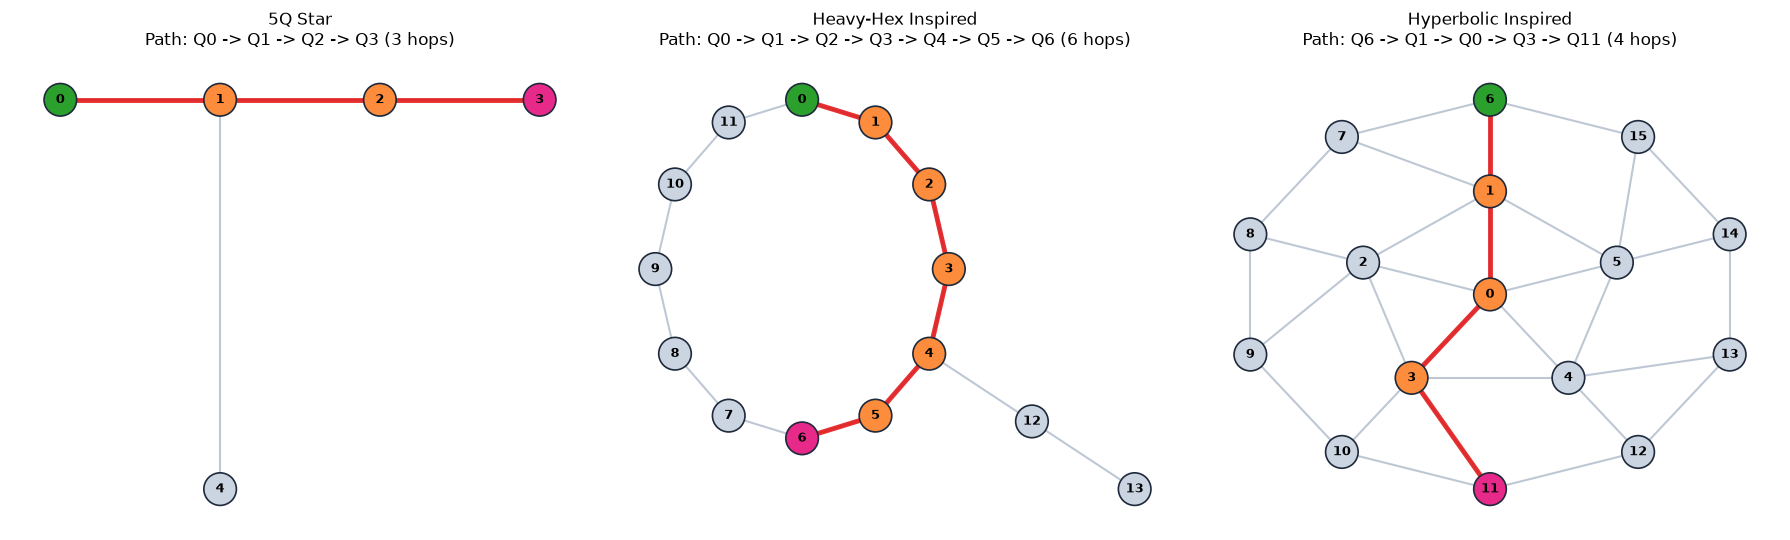

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (name, topo) in zip(axes, topologies.items()):
    g = topo.graph
    pos = topo.pos
    path = topo.shortest_path()
    path_edges = list(zip(path[:-1], path[1:]))
    
    # Base edges
    nx.draw_networkx_edges(g, pos, ax=ax, edge_color="#94a3b8", width=1.5, alpha=0.6)
    # Highlighted shortest routing path
    nx.draw_networkx_edges(g, pos, edgelist=path_edges, ax=ax, edge_color="#e41a1c", width=3.5, alpha=0.9)
    
    node_colors = []
    for node in g.nodes():
        if node == topo.source:
            node_colors.append("#2ca02c")      # Source: Green
        elif node == topo.destination:
            node_colors.append("#e7298a")      # Destination: Magenta
        elif node in path:
            node_colors.append("#fd8d3c")      # Intermediate: Orange
        else:
            node_colors.append("#cbd5e1")      # Idle: Slate
            
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color=node_colors, node_size=550, edgecolors="#1e293b", linewidths=1.2)
    nx.draw_networkx_labels(g, pos, ax=ax, font_size=9, font_weight="bold")
    ax.set_title(f"{name}\nPath: {' -> '.join(f'Q{n}' for n in path)} ({len(path)-1} hops)", pad=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Topology-Aware Routing & SWAP Restoration

Given shortest path $P = [p_0, p_1, \dots, p_k]$ ($p_0 = s, p_k = d$):
1. Apply $H(p_0)$ on the source qubit.
2. Shutter forward via sequential SWAPs: $\text{SWAP}(p_i, p_{i+1})$ for $i = 0, \dots, k-2$.
3. Execute the entangling gate: $CX(p_{k-1}, p_k)$.
4. Apply the reverse sequence of SWAPs from $k-2$ down to 0.

### Circuit Depth Metric:
- **Primary Metric: Transpiled/Routed Circuit Depth (DAG):** Directly computed from the Qiskit QuantumCircuit DAG layers ($2 \times \text{hops}$).
  - 5Q Star: 6 time-slices
  - Heavy-Hex: 12 time-slices
  - Hyperbolic: 8 time-slices
- **Secondary Estimate: Serialized Gate Depth:** Sequential time-slice estimate ($2 \times N_{\text{SWAP}} + 1$).


In [3]:
for name, topo in topologies.items():
    qc, rm = build_routed_bell_circuit(topo, measurement_basis="Z")
    print(f"[{name}]")
    print(f"  Routing Path            : {' -> '.join(str(n) for n in rm.path)} ({rm.path_length} hops)")
    print(f"  Actual SWAPs            : {rm.num_swaps}")
    print(f"  Total Two-Qubit Gates   : {rm.total_two_qubit_gates} (SWAPs + 1 CX)")
    print(f"  Routed Circuit Depth    : {rm.circuit_depth} (Primary metric from Qiskit DAG)")
    print(f"  Est. Serialized Depth   : {2 * rm.num_swaps + 1} (Secondary serialized estimate)\n")


[5Q Star]
  Routing Path            : 0 -> 1 -> 2 -> 3 (3 hops)
  Actual SWAPs            : 4
  Total Two-Qubit Gates   : 5 (SWAPs + 1 CX)
  Routed Circuit Depth    : 6 (Primary metric from Qiskit DAG)
  Est. Serialized Depth   : 9 (Secondary serialized estimate)

[Heavy-Hex Inspired]
  Routing Path            : 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6 (6 hops)
  Actual SWAPs            : 10
  Total Two-Qubit Gates   : 11 (SWAPs + 1 CX)
  Routed Circuit Depth    : 12 (Primary metric from Qiskit DAG)
  Est. Serialized Depth   : 21 (Secondary serialized estimate)

[Hyperbolic Inspired]
  Routing Path            : 6 -> 1 -> 0 -> 3 -> 11 (4 hops)
  Actual SWAPs            : 6
  Total Two-Qubit Gates   : 7 (SWAPs + 1 CX)
  Routed Circuit Depth    : 8 (Primary metric from Qiskit DAG)
  Est. Serialized Depth   : 13 (Secondary serialized estimate)



## 6. Ideal Baseline & Statevector Cross-Check

We simulate the unmeasured and measured circuits under an ideal noise-free environment.
We cross-check the shot-based tomographic fidelity with the exact mathematical Statevector fidelity.


In [4]:
for name, topo in topologies.items():
    sv_fid = cross_check_statevector_fidelity(topo)
    print(f"{name:<22}: Exact Mathematical Statevector Fidelity = {sv_fid:.6f}")


5Q Star               : Exact Mathematical Statevector Fidelity = 1.000000
Heavy-Hex Inspired    : Exact Mathematical Statevector Fidelity = 1.000000
Hyperbolic Inspired   : Exact Mathematical Statevector Fidelity = 1.000000


## 7. Controlled Noise Model (Qiskit Aer)

To guarantee a fair, controlled comparison across topologies, we apply an identical, realistic noise model to all architectures:
- **1-Qubit Gate Depolarizing Error:** $p_1 = 0.10\%$ on $H, S, S^\dagger$
- **2-Qubit Gate Depolarizing Error:** $p_2 = 1.50\%$ on $CX, SWAP$
- **Readout Assignment Error:** $p_{0|1} = p_{1|0} = 2.00\%$
- **Sample Size:** 20,000 shots per Pauli basis ($X, Y, Z$) with `seed=42`.

*Note: We use a common configurable simulated noise model so that topology comparisons remain controlled.*


In [5]:
noise_cfg = NoiseConfig(p1_gate_error=0.001, p2_gate_error=0.015, readout_error=0.02)
print("Configured Noise Model:", noise_cfg.summary())


Configured Noise Model: 1Q Depolarizing: 0.10%, 2Q Depolarizing: 1.50%, Readout Error: 2.00%


## 8. Protection: Stabilizer/Parity Verification with Post-Selection

### Scientific Mechanism:
In the fault-free circuit, intermediate routing qubits $p_1, \dots, p_{k-1}$ undergo symmetric forward-and-reverse SWAPs and deterministically return to state $\vert 0 \rangle$.
In a noisy execution, depolarizing and bit-flip errors during transport flip intermediate qubits into $\vert 1 \rangle$.

We measure all intermediate routing qubits into syndrome bits:
- **Post-Selection Condition:** Accept shot if and only if **all intermediate syndrome bits measure 0**.
- **Survival Yield ($\eta$):**
$$\eta = \frac{N_{\text{accepted}}}{N_{\text{total}}}$$
- **Protected Fidelity:** Recomputed from accepted shots.

*Scientific Rigor Note: This is explicitly labeled as stabilizer/parity verification with post-selection, rather than full fault-tolerant quantum error correction.*


## 9. The Complete 9-Case Benchmark Matrix & Results

We execute all 9 benchmark cases across the 3 topologies and 3 conditions (Ideal, Noisy, Noisy + Protection).


In [6]:
df_results, geom_metrics, comparisons = run_full_benchmark(
    noise_config=noise_cfg,
    shots=20000,
    seed=42,
    output_csv_path="../results/benchmark_results.csv"
)

print("=" * 96)
print("                              THE 9-CASE BENCHMARK RESULTS")
print("=" * 96)
print(df_results.to_string(index=False))
print("=" * 96)


                              THE 9-CASE BENCHMARK RESULTS
           Topology          Condition  Fidelity     XX      YY     ZZ  SWAPs  2Q Gates  Depth  Survival Yield
            5Q Star              Ideal    1.0000 1.0000 -1.0000 1.0000      4         5      6          1.0000
            5Q Star              Noisy    0.8972 0.8526 -0.8568 0.8795      4         5      6          1.0000
            5Q Star Noisy + Protection    0.9116 0.8751 -0.8803 0.8911      4         5      6          0.9341
 Heavy-Hex Inspired              Ideal    1.0000 1.0000 -1.0000 1.0000     10        11     12          1.0000
 Heavy-Hex Inspired              Noisy    0.8513 0.7760 -0.7877 0.8414     10        11     12          1.0000
 Heavy-Hex Inspired Noisy + Protection    0.8856 0.8349 -0.8387 0.8688     10        11     12          0.8448
Hyperbolic Inspired              Ideal    1.0000 1.0000 -1.0000 1.0000      6         7      8          1.0000
Hyperbolic Inspired              Noisy    0.8828 0.82

## 10. Comparative Visualizations

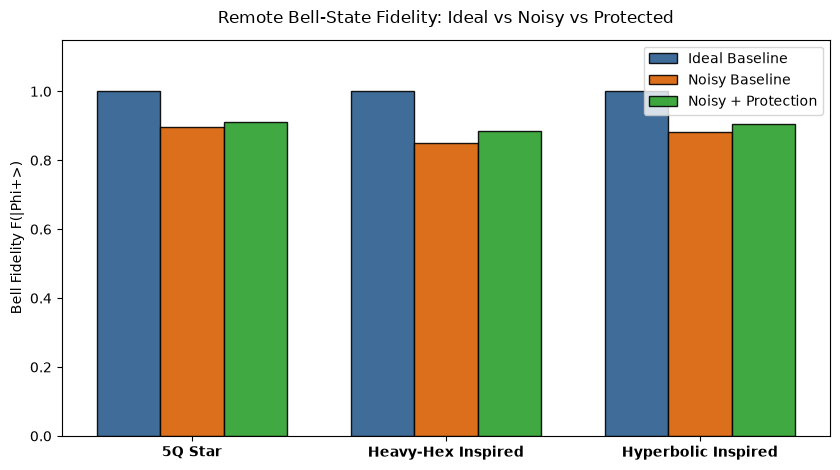

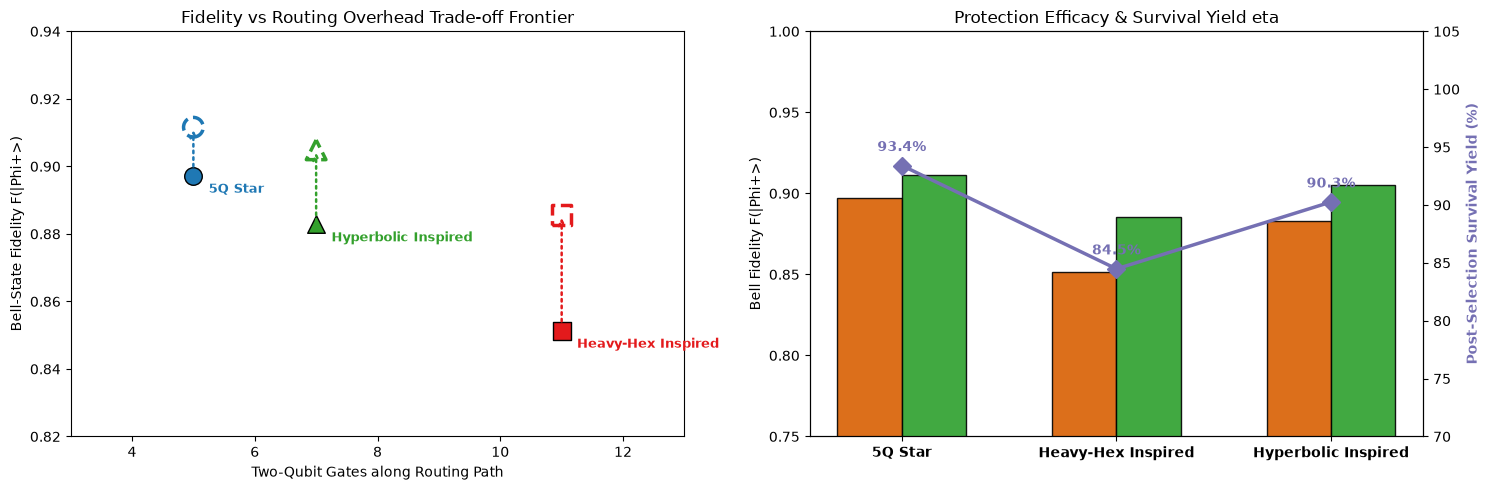

In [7]:
# 1. Fidelity Comparison
fig, ax = plt.subplots(figsize=(8.5, 4.8))
topos = df_results["Topology"].unique()
x = np.arange(len(topos))
width = 0.25

ideal_vals = [df_results[(df_results["Topology"] == t) & (df_results["Condition"] == "Ideal")]["Fidelity"].values[0] for t in topos]
noisy_vals = [df_results[(df_results["Topology"] == t) & (df_results["Condition"] == "Noisy")]["Fidelity"].values[0] for t in topos]
prot_vals = [df_results[(df_results["Topology"] == t) & (df_results["Condition"] == "Noisy + Protection")]["Fidelity"].values[0] for t in topos]

ax.bar(x - width, ideal_vals, width, label="Ideal Baseline", color="#2b5c8f", alpha=0.9, edgecolor="black")
ax.bar(x, noisy_vals, width, label="Noisy Baseline", color="#d95f02", alpha=0.9, edgecolor="black")
ax.bar(x + width, prot_vals, width, label="Noisy + Protection", color="#2ca02c", alpha=0.9, edgecolor="black")

ax.set_ylabel("Bell Fidelity F(|Phi+>)")
ax.set_title("Remote Bell-State Fidelity: Ideal vs Noisy vs Protected", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(topos, fontweight="bold")
ax.set_ylim(0.0, 1.15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# 2. Trade-Off Frontier & Protection Yield
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
markers = {"5Q Star": "o", "Heavy-Hex Inspired": "s", "Hyperbolic Inspired": "^"}
colors = {"5Q Star": "#1f78b4", "Heavy-Hex Inspired": "#e31a1c", "Hyperbolic Inspired": "#33a02c"}

for topo in topos:
    row_n = df_results[(df_results["Topology"] == topo) & (df_results["Condition"] == "Noisy")].iloc[0]
    row_p = df_results[(df_results["Topology"] == topo) & (df_results["Condition"] == "Noisy + Protection")].iloc[0]
    gates = row_n["2Q Gates"]
    
    ax1.scatter(gates, row_n["Fidelity"], color=colors[topo], marker=markers[topo], s=160, edgecolor="black", label=f"{topo} (Noisy)")
    ax1.scatter(gates, row_p["Fidelity"], color=colors[topo], marker=markers[topo], s=200, facecolors="none", linewidths=2.5, linestyle="--", label=f"{topo} (Protected)")
    ax1.annotate("", xy=(gates, row_p["Fidelity"]), xytext=(gates, row_n["Fidelity"]), arrowprops=dict(arrowstyle="->", color=colors[topo], lw=1.8, ls=":"))
    ax1.text(gates + 0.25, row_n["Fidelity"] - 0.005, f"{topo}", fontsize=9, fontweight="bold", color=colors[topo])

ax1.set_xlabel("Two-Qubit Gates along Routing Path")
ax1.set_ylabel("Bell-State Fidelity F(|Phi+>)")
ax1.set_title("Fidelity vs Routing Overhead Trade-off Frontier")
ax1.set_xlim(3, 13)
ax1.set_ylim(0.82, 0.94)

width = 0.3
x = np.arange(len(topos))
yields = [df_results[(df_results["Topology"] == t) & (df_results["Condition"] == "Noisy + Protection")]["Survival Yield"].values[0] * 100 for t in topos]

ax2.bar(x - width/2, noisy_vals, width, label="Noisy Fidelity", color="#d95f02", alpha=0.9, edgecolor="black")
ax2.bar(x + width/2, prot_vals, width, label="Protected Fidelity", color="#2ca02c", alpha=0.9, edgecolor="black")
ax2.set_ylabel("Bell Fidelity F(|Phi+>)")
ax2.set_ylim(0.75, 1.0)
ax2.set_xticks(x)
ax2.set_xticklabels(topos, fontweight="bold")

ax2_twin = ax2.twinx()
ax2_twin.plot(x, yields, color="#7570b3", marker="D", markersize=9, linewidth=2.5, label="Survival Yield (%)")
ax2_twin.set_ylabel("Post-Selection Survival Yield (%)", color="#7570b3", fontweight="bold")
ax2_twin.set_ylim(70, 105)
ax2_twin.grid(False)

for i, y in enumerate(yields):
    ax2_twin.annotate(f"{y:.1f}%", xy=(x[i], y), xytext=(0, 8), textcoords="offset points", ha="center", va="bottom", color="#7570b3", fontweight="bold")

ax2.set_title("Protection Efficacy & Survival Yield eta")
plt.tight_layout()
plt.show()


## 11. Architectural Interpretation & Composite Score

$$\text{Composite Score} = \frac{\text{Fidelity}}{1 + \text{Normalized Routing Cost}}$$


In [8]:
print(f"{'Topology':<22} | {'Noisy Fid':<10} | {'Protected Fid':<13} | {'Survival Yield':<14} | {'Fidelity Gain':<13} | {'Composite Score'}")
print("-" * 95)
for name, comp in comparisons.items():
    print(f"{name:<22} | {comp.noisy_fidelity:<10.4f} | {comp.protected_fidelity:<13.4f} | "
          f"{comp.survival_yield*100:<13.1f}% | +{comp.protection_fidelity_gain:<12.4f} | {comp.noisy_composite_score:<15.4f}")


Topology               | Noisy Fid  | Protected Fid | Survival Yield | Fidelity Gain | Composite Score
-----------------------------------------------------------------------------------------------
5Q Star                | 0.8972     | 0.9116        | 93.4         % | +0.0144       | 0.8972         
Heavy-Hex Inspired     | 0.8513     | 0.8856        | 84.5         % | +0.0343       | 0.3869         
Hyperbolic Inspired    | 0.8828     | 0.9049        | 90.3         % | +0.0221       | 0.6306         


## 12. Recommendation & Limitations

### Scientifically Defensible Conclusion:
**In our simulated benchmark, the hyperbolic-inspired topology achieved lower routing overhead than the tested heavy-hex-inspired topology for the selected remote-qubit configuration:**
- **SWAP Overhead:** Hyperbolic required **6 SWAPs** vs Heavy-Hex's **10 SWAPs** (40% reduction).
- **Circuit Depth:** Hyperbolic routed DAG depth was **8** vs Heavy-Hex's **12** (33% reduction).
- **Fidelity Retention:** Hyperbolic noisy fidelity was **0.8828** vs **0.8513** for Heavy-Hex under identical noise.
- **Protection Yield:** Stabilizer post-selection achieved **0.9049** with **90.3% survival yield** on Hyperbolic, vs **84.5% yield** on Heavy-Hex.
- **5Q Star Context:** The 5-qubit star topology has the lowest absolute routing overhead because it is a much smaller graph (5 nodes vs 14–16 nodes); this comparison illustrates how connectivity geometry dictates routing scaling rather than declaring the smallest processor the winner.

### Fair-Comparison Limitations:
1. **Representative Simulated Graphs:** The heavy-hex and hyperbolic models are representative simulated graphs with different sizes (14 vs 16 qubits) and connectivity structures. Results depend on selected source/target pairs and the chosen noise model. Therefore, the benchmark demonstrates the effect of topology under controlled simulation conditions rather than proving universal hardware superiority.
2. **Simulation Scope:** Numerical simulation in Qiskit Aer, not a physical cryogenic hardware experiment.
3. **Protection Scope:** Stabilizer/parity verification with post-selection filters out corrupted trajectories, but does not perform active fault-tolerant QEC.
